<a href="https://colab.research.google.com/github/sudip328/Random-Forest-Cs2GeX6-/blob/main/Lasso%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)

df

,Compound,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy,Band_gap
0,Cs2GeF6,9.23,786.86,1.14,0.398,-4.78,5.910
1,Cs2GeCl6,10.59,1187.00,1.05,0.293,-3.38,2.260
2,Cs2GeBr6,11.09,1365.11,1.03,0.271,-2.72,1.016
3,Cs2GeI6,11.70,1601.50,1.00,0.241,-1.03,0.000


In [3]:
feature_columns = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

target_column = "Band_gap"

X = df[feature_columns]
y = df[target_column]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Lattice_parameter   Volume  Tolerance_factor  Octahedral_factor  \
0               9.23   786.86              1.14              0.398   
1              10.59  1187.00              1.05              0.293   
2              11.09  1365.11              1.03              0.271   
3              11.70  1601.50              1.00              0.241   

   Formation_energy  
0             -4.78  
1             -3.38  
2             -2.72  
3             -1.03  

Target:
0    5.910
1    2.260
2    1.016
3    0.000
Name: Band_gap, dtype: float64


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=feature_columns,
    index=X.index
)

print("Scaled features:")
print(X_scaled)

Scaled features:
   Lattice_parameter    Volume  Tolerance_factor  Octahedral_factor  \
0          -1.562320 -1.505984          1.628305           1.645427   
1          -0.068643 -0.161657         -0.095783          -0.131127   
2           0.480503  0.436728         -0.478913          -0.503357   
3           1.150461  1.230913         -1.053609          -1.010944   

   Formation_energy  
0         -1.337014  
1         -0.298556  
2          0.191002  
3          1.444568  


In [5]:
alpha = 0.01

In [6]:
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000,
    random_state=42
)

lasso_model.fit(X_scaled, y)

print("Lasso model trained successfully!")

Lasso model trained successfully!


In [7]:
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

In [8]:
y_pred = lasso_model.predict(X_scaled)

results = pd.DataFrame({
    "Compound": df["Compound"],
    "Actual_Band_Gap": y,
    "Predicted_Band_Gap": y_pred
})

results

NotFittedError: This Lasso instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# DATA
# ============================================================

data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)

# ============================================================
# FEATURES AND TARGET
# ============================================================

feature_columns = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

X = df[feature_columns]
y = df["Band_gap"]

print("Dataset:")
display(df)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Dataset:


,Compound,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy,Band_gap
0,Cs2GeF6,9.23,786.86,1.14,0.398,-4.78,5.910
1,Cs2GeCl6,10.59,1187.00,1.05,0.293,-3.38,2.260
2,Cs2GeBr6,11.09,1365.11,1.03,0.271,-2.72,1.016
3,Cs2GeI6,11.70,1601.50,1.00,0.241,-1.03,0.000



X shape: (4, 5)
y shape: (4,)


In [10]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=feature_columns
)

print("Scaled features:")
display(X_scaled)

Scaled features:


,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy
0,-1.562320,-1.505984,1.628305,1.645427,-1.337014
1,-0.068643,-0.161657,-0.095783,-0.131127,-0.298556
2,0.480503,0.436728,-0.478913,-0.503357,0.191002
3,1.150461,1.230913,-1.053609,-1.010944,1.444568


In [11]:
# ============================================================
# LASSO MODEL TRAINING
# ============================================================

alpha = 0.01

lasso_model = Lasso(
    alpha=alpha,
    max_iter=10000
)

# IMPORTANT: FIT THE MODEL
lasso_model.fit(X_scaled, y)

print("Lasso model fitted successfully!")

Lasso model fitted successfully!


In [12]:
lasso_model.predict(...)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got scalar array instead:
array=Ellipsis.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [13]:
# ============================================================
# BAND GAP PREDICTION
# ============================================================

y_pred = lasso_model.predict(X_scaled)

results = pd.DataFrame({
    "Compound": df["Compound"],
    "Actual_Band_Gap": y,
    "Predicted_Band_Gap": y_pred
})

display(results)

,Compound,Actual_Band_Gap,Predicted_Band_Gap
0,Cs2GeF6,5.910,5.888425
1,Cs2GeCl6,2.260,2.176131
2,Cs2GeBr6,1.016,1.195478
3,Cs2GeI6,0.000,-0.074034


In [14]:
# ============================================================
# TRAINING EVALUATION
# ============================================================

train_rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

train_mae = mean_absolute_error(
    y, y_pred
)

train_r2 = r2_score(
    y, y_pred
)

print("===== LASSO TRAINING PERFORMANCE =====")
print(f"RMSE = {train_rmse:.4f} eV")
print(f"MAE  = {train_mae:.4f} eV")
print(f"R²   = {train_r2:.4f}")

===== LASSO TRAINING PERFORMANCE =====
RMSE = 0.1063 eV
MAE  = 0.0897 eV
R²   = 0.9977


In [15]:
# ============================================================
# LASSO COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": lasso_model.coef_
})

display(coefficients)

print("Intercept:", lasso_model.intercept_)

,Feature,Coefficient
0,Lattice_parameter,-0.858813
1,Volume,-0.000000
2,Tolerance_factor,0.000000
3,Octahedral_factor,1.367538
4,Formation_energy,0.000000


Intercept: 2.2965000000000004


In [16]:
# ============================================================
# LEAVE-ONE-OUT CROSS VALIDATION
# ============================================================

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    # -------------------------
    # Split data
    # -------------------------

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # -------------------------
    # Scale training data
    # -------------------------

    scaler_loo = StandardScaler()

    X_train_scaled = scaler_loo.fit_transform(X_train)

    X_test_scaled = scaler_loo.transform(X_test)

    # -------------------------
    # Create new Lasso model
    # -------------------------

    lasso_loo = Lasso(
        alpha=0.01,
        max_iter=10000
    )

    # -------------------------
    # Fit model
    # -------------------------

    lasso_loo.fit(
        X_train_scaled,
        y_train
    )

    # -------------------------
    # Predict left-out sample
    # -------------------------

    prediction = lasso_loo.predict(
        X_test_scaled
    )

    loo_predictions.append(prediction[0])
    loo_actual.append(y_test.iloc[0])
    loo_compounds.append(
        df["Compound"].iloc[test_index[0]]
    )


# ============================================================
# LOOCV RESULTS
# ============================================================

loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

display(loo_results)

,Compound,Actual_Band_Gap,LOOCV_Predicted_Band_Gap
0,Cs2GeF6,5.910,4.898009
1,Cs2GeCl6,2.260,1.918479
2,Cs2GeBr6,1.016,1.313157
3,Cs2GeI6,0.000,-0.529883


In [17]:
# ============================================================
# TRAINING vs LOOCV
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "RMSE (eV)",
        "MAE (eV)",
        "R²"
    ],

    "Training": [
        train_rmse,
        train_mae,
        train_r2
    ],

    "LOOCV": [
        loo_rmse,
        loo_mae,
        loo_r2
    ]
})

display(comparison)

NameError: name 'loo_rmse' is not defined

In [18]:
# ============================================================
# COMPLETE LASSO + LOOCV ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ------------------------------------------------------------
# 1. DATA
# ------------------------------------------------------------

data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)


# ------------------------------------------------------------
# 2. FEATURES AND TARGET
# ------------------------------------------------------------

features = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

X = df[features]
y = df["Band_gap"]


# ------------------------------------------------------------
# 3. TRAINING MODEL
# ------------------------------------------------------------

# Scale features for Lasso
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Create Lasso model
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

# FIT the model
lasso_model.fit(X_scaled, y)

# Training predictions
y_pred = lasso_model.predict(X_scaled)


# ------------------------------------------------------------
# 4. TRAINING PERFORMANCE
# ------------------------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

train_mae = mean_absolute_error(
    y, y_pred
)

train_r2 = r2_score(
    y, y_pred
)


# ------------------------------------------------------------
# 5. LOOCV
# ------------------------------------------------------------

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    # Split data
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Scale ONLY training data
    scaler_loo = StandardScaler()

    X_train_scaled = scaler_loo.fit_transform(X_train)

    X_test_scaled = scaler_loo.transform(X_test)

    # Create Lasso model
    lasso_loo = Lasso(
        alpha=0.01,
        max_iter=10000
    )

    # FIT
    lasso_loo.fit(
        X_train_scaled,
        y_train
    )

    # Predict left-out sample
    prediction = lasso_loo.predict(
        X_test_scaled
    )

    loo_predictions.append(prediction[0])
    loo_actual.append(y_test.iloc[0])
    loo_compounds.append(
        df["Compound"].iloc[test_index[0]]
    )


# ------------------------------------------------------------
# 6. LOOCV PERFORMANCE
# ------------------------------------------------------------

loo_rmse = np.sqrt(
    mean_squared_error(
        loo_actual,
        loo_predictions
    )
)

loo_mae = mean_absolute_error(
    loo_actual,
    loo_predictions
)

loo_r2 = r2_score(
    loo_actual,
    loo_predictions
)


# ------------------------------------------------------------
# 7. RESULTS TABLE
# ------------------------------------------------------------

loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

loo_results["Absolute_Error"] = abs(
    loo_results["Actual_Band_Gap"]
    -
    loo_results["LOOCV_Predicted_Band_Gap"]
)


# ------------------------------------------------------------
# 8. PRINT RESULTS
# ------------------------------------------------------------

print("=" * 55)
print("           LASSO REGRESSION RESULTS")
print("=" * 55)

print("\nTRAINING PERFORMANCE")
print(f"RMSE = {train_rmse:.4f} eV")
print(f"MAE  = {train_mae:.4f} eV")
print(f"R²   = {train_r2:.4f}")

print("\nLOOCV PERFORMANCE")
print(f"RMSE = {loo_rmse:.4f} eV")
print(f"MAE  = {loo_mae:.4f} eV")
print(f"R²   = {loo_r2:.4f}")

print("\nLOOCV PREDICTIONS")
display(loo_results)

           LASSO REGRESSION RESULTS

TRAINING PERFORMANCE
RMSE = 0.1063 eV
MAE  = 0.0897 eV
R²   = 0.9977

LOOCV PERFORMANCE
RMSE = 0.6144 eV
MAE  = 0.5451 eV
R²   = 0.9244

LOOCV PREDICTIONS


,Compound,Actual_Band_Gap,LOOCV_Predicted_Band_Gap,Absolute_Error
0,Cs2GeF6,5.910,4.898009,1.011991
1,Cs2GeCl6,2.260,1.918479,0.341521
2,Cs2GeBr6,1.016,1.313157,0.297157
3,Cs2GeI6,0.000,-0.529883,0.529883


In [19]:
# ============================================================
# TRAINING vs LOOCV
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "RMSE (eV)",
        "MAE (eV)",
        "R²"
    ],

    "Training": [
        train_rmse,
        train_mae,
        train_r2
    ],

    "LOOCV": [
        loo_rmse,
        loo_mae,
        loo_r2
    ]
})

display(comparison)

,Metric,Training,LOOCV
0,RMSE (eV),0.106293,0.614378
1,MAE (eV),0.089739,0.545138
2,R²,0.997737,0.924403


In [20]:
# ============================================================
# LASSO COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lasso_model.coef_
})

display(coefficients)

print("Intercept:", lasso_model.intercept_)

,Feature,Coefficient
0,Lattice_parameter,-0.858813
1,Volume,-0.000000
2,Tolerance_factor,0.000000
3,Octahedral_factor,1.367538
4,Formation_energy,0.000000


Intercept: 2.2965000000000004


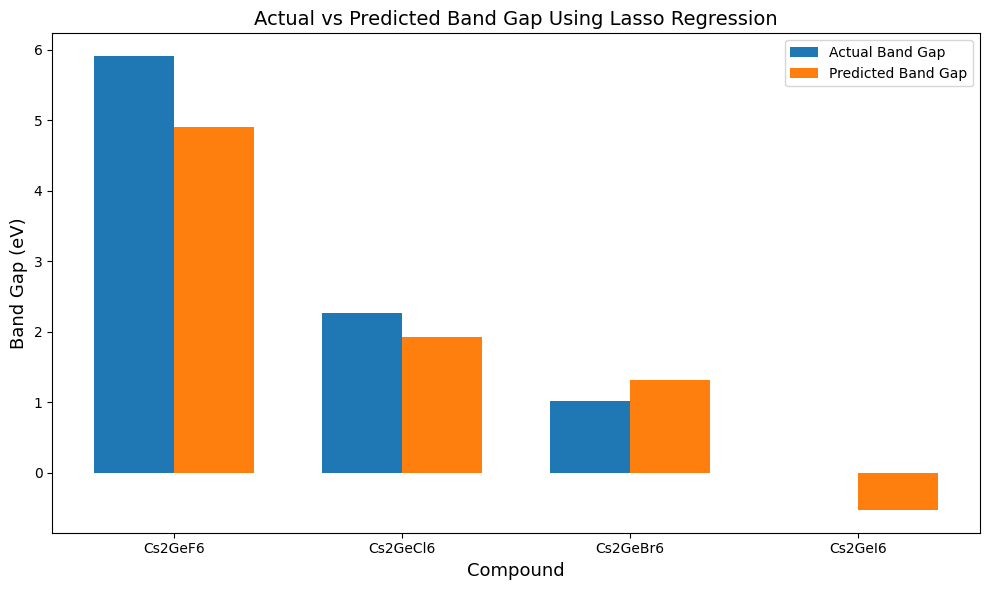

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create x positions
x = np.arange(len(loo_compounds))
width = 0.35

# Create the plot
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    loo_actual,
    width,
    label='Actual Band Gap'
)

plt.bar(
    x + width/2,
    loo_predictions,
    width,
    label='Predicted Band Gap'
)

# Labels and formatting
plt.xlabel('Compound', fontsize=13)
plt.ylabel('Band Gap (eV)', fontsize=13)
plt.title('Actual vs Predicted Band Gap Using Lasso Regression', fontsize=14)

plt.xticks(x, loo_compounds, rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

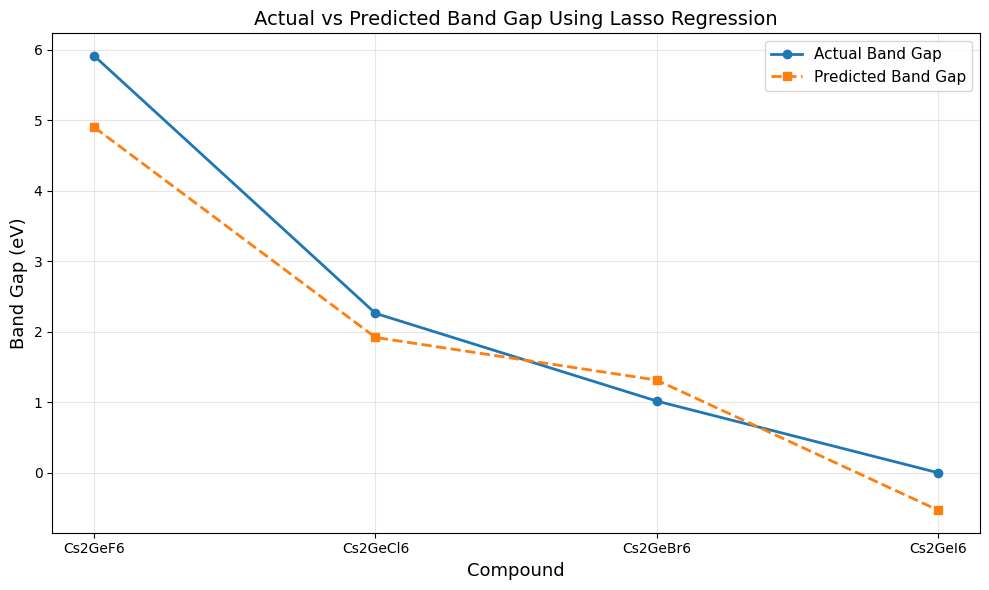

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Actual band gap
plt.plot(
    loo_compounds,
    loo_actual,
    marker='o',
    linewidth=2,
    label='Actual Band Gap'
)

# Predicted band gap
plt.plot(
    loo_compounds,
    loo_predictions,
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Predicted Band Gap'
)

# Axis labels
plt.xlabel('Compound', fontsize=13)
plt.ylabel('Band Gap (eV)', fontsize=13)

# Title
plt.title('Actual vs Predicted Band Gap Using Lasso Regression', fontsize=14)

# Formatting
plt.xticks(rotation=0)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()